### Прогноз цен на недвижимость

Курсовой проект по машинному обучению (4 курс, 1 семестр).
Авторы: Эрнест и Иршат.
Датасет: объявления о продаже недвижимости с портала Zingat.
Цель: исследовать данные, подготовить признаки и обучить модели регрессии для прогнозирования стоимости объектов.


In [1]:
# подключаем библиотеки для работы с данными, графиками и ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Этап 1. Исследование данных (EDA)

### 1.1 Знакомство с данными
Загружаем датасет, смотрим его размерность, первые, последние и случайные строки.


In [2]:
# читаем датасет из папки data
df = pd.read_csv("../data/real_estate_data.csv", low_memory=False)
print("Размер датасета (строк, колонок):", df.shape)
# выводим первые 5 строк
df.head()

Размер датасета (строк, колонок): (403487, 17)


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [3]:
# смотрим последние 5 строк
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [4]:
# выводим одну случайную строку для проверки разнообразия данных
df.sample(1, random_state=42)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


### Описание признаков датасета (по документации Zingat)

* **id**: уникальный идентификатор объявления
* **type**: тип объекта (Konut - жилье)
* **sub_type**: подтип жилья (Daire - квартира, Villa - вилла, Rezidans - резиденция)
* **start_date** / **end_date**: даты публикации и снятия с сайта
* **listing_type**: тип сделки (1 - продажа, 2 - аренда)
* **tom**: дней на рынке (time on market)
* **building_age**: возраст строения (0, 1, 2, 6-10 arasi и т.д.)
* **total_floor_count**: этажность здания
* **floor_no**: этаж квартиры
* **room_count**: число комнат (формат 2+1, 3+1)
* **size**: общая площадь в м2
* **address**: город / район / микрорайон
* **furnished**: меблировка (100% пропусков)
* **heating_type**: система отопления (Kombi, Merkezi Sistem и др.)
* **price**: цена объекта в турецких лирах (целевая переменная)
* **price_currency**: валюта (TRY)


In [5]:
# типы данных и ненулевые значения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

### 1.2 Описательная статистика и анализ целевой переменной


In [6]:
# базовые статистики числовых колонок: минимум, максимум, среднее, квантили
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


In [7]:
# статистика категориальных признаков: количество уникальных и самый частый класс
df.describe(include='O')

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,35,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,65864,157363,5611,204150,400677


In [8]:
# проверяем скошенность (асимметрию) цены:
# положительный коэффициент говорит о сильном хвосте вправо (дорогие элитные объекты)
print("Коэффициент асимметрии цены:", df['price'].skew())
print("Асимметрия после log1p:", np.log1p(df['price'].dropna()).skew())

Коэффициент асимметрии цены: 308.50702657456833
Асимметрия после log1p: -0.813924910010576


### 1.3 Визуальный анализ данных (5+ типов графиков)


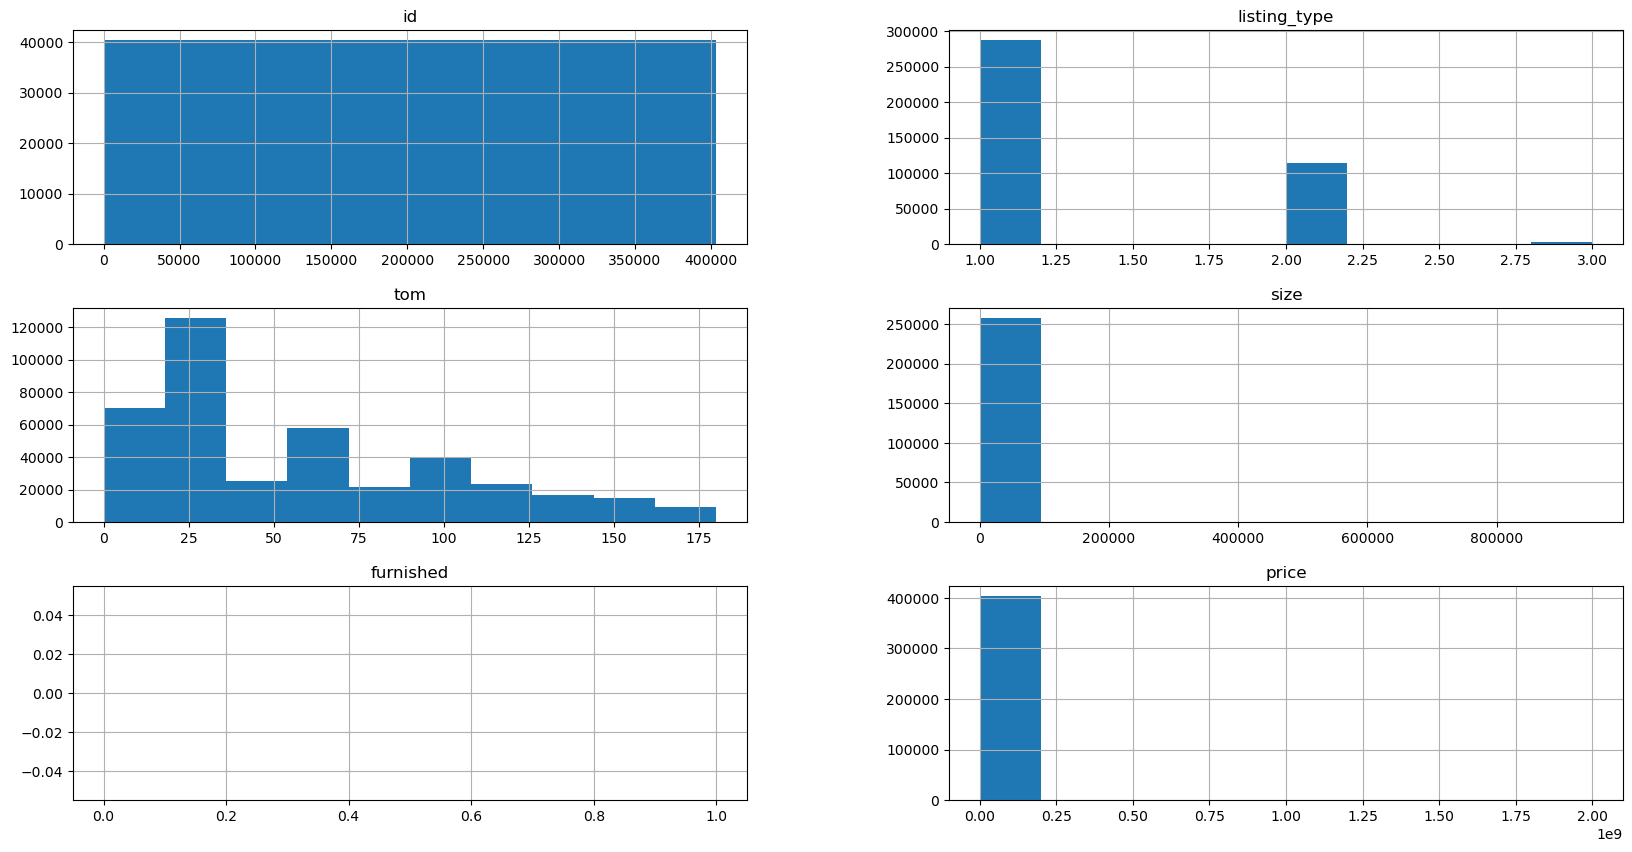

In [9]:
# 1. Гистограммы распределения всех числовых признаков
df.hist(figsize=(20, 10))
plt.show()

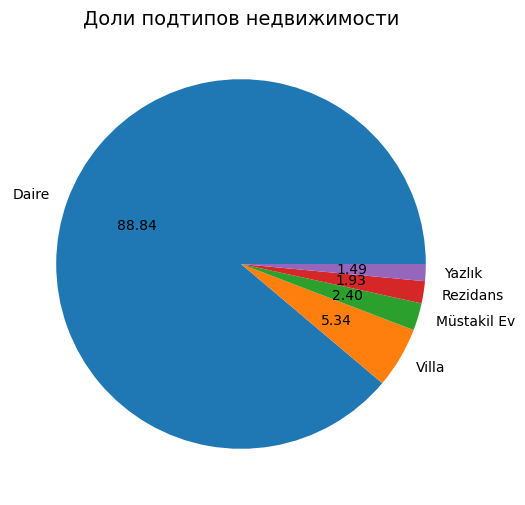

In [10]:
# 2. Круговая диаграмма долей подтипов недвижимости
plt.figure(figsize=(8, 6))
df['sub_type'].value_counts().head(5).plot(kind='pie', autopct='%.2f', textprops={'color': 'black'})
plt.title('Доли подтипов недвижимости', fontsize=14)
plt.ylabel('')
plt.show()

Больше 85% всех объявлений в датасете - это квартиры (Daire).


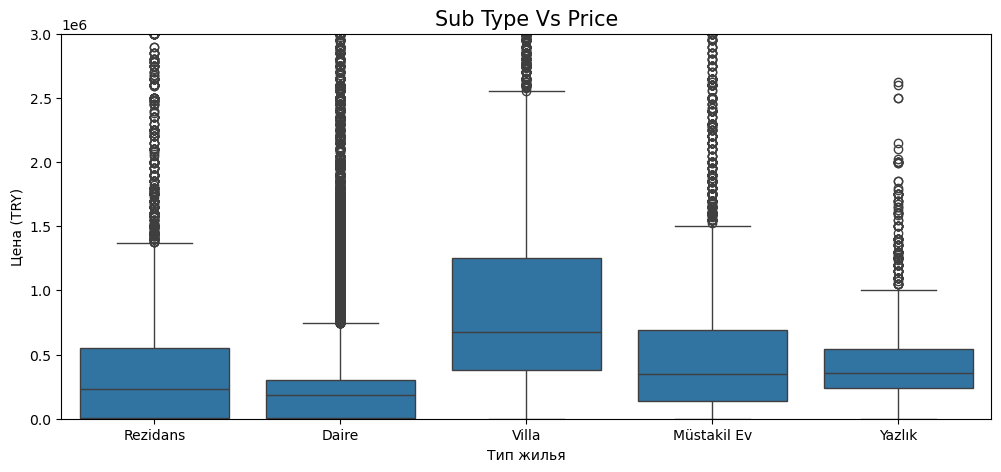

In [11]:
# 3. Boxplot: распределение цены по подтипам недвижимости
top_subtypes = df['sub_type'].value_counts().head(5).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['sub_type'].isin(top_subtypes)], x='sub_type', y='price')
plt.title('Sub Type Vs Price', fontsize=15)
plt.xlabel('Тип жилья')
plt.ylabel('Цена (TRY)')
plt.ylim(0, 3000000)
plt.show()

Виллы и резиденции стоят ощутимо дороже типовых квартир.


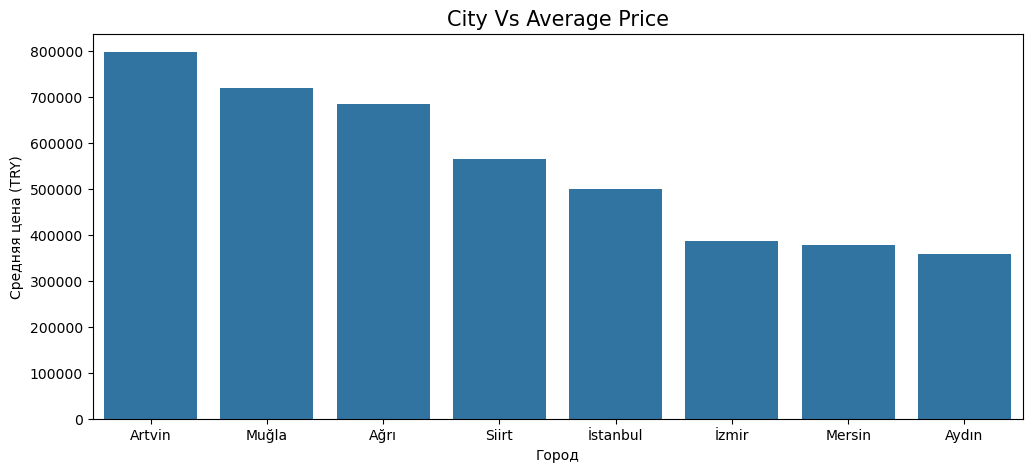

In [12]:
# 4. Столбчатая диаграмма средних цен по городам
df['city'] = df['address'].apply(lambda x: str(x).split('/')[0] if '/' in str(x) else 'Diger')
city_mean = df.groupby('city')['price'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 5))
sns.barplot(x=city_mean.index, y=city_mean.values)
plt.title('City Vs Average Price', fontsize=15)
plt.xlabel('Город')
plt.ylabel('Средняя цена (TRY)')
plt.show()

Стамбул и курортные города (Мугла, Анталья) лидируют по средней стоимости жилья.


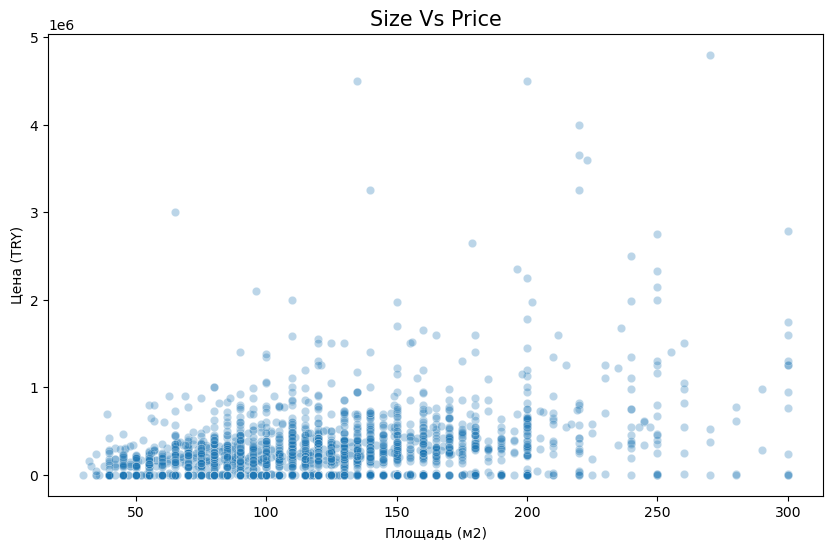

In [13]:
# 5. Scatterplot (точечная диаграмма): зависимость цены от площади
sample_data = df[(df['size'] >= 30) & (df['size'] <= 300) & (df['price'] <= 5000000)].sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_data, x='size', y='price', alpha=0.3)
plt.title('Size Vs Price', fontsize=15)
plt.xlabel('Площадь (м2)')
plt.ylabel('Цена (TRY)')
plt.show()

Видна прямая зависимость: чем больше площадь квартиры, тем выше цена.


### 1.4 Анализ пропусков, дубликатов и аномалий


In [14]:
# таблица пропусков по колонкам
null_info = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df) * 100).round(2)
})
null_info[null_info['Пропусков'] > 0]

,Пропусков,Процент
end_date,137189,34.00
building_age,27390,6.79
total_floor_count,28021,6.94
floor_no,35296,8.75
size,146006,36.19
furnished,403487,100.00
heating_type,27970,6.93
price,715,0.18
price_currency,715,0.18


In [15]:
# проверяем наличие полных дубликатов строк
print("Количество полных дубликатов:", df.duplicated().sum())

# проверяем нереалистичные значения (цена <= 0, площадь <= 0)
bad_prices = (df['price'] <= 0).sum()
bad_sizes = (df['size'] <= 0).sum()
print("Записей с нулевой или отрицательной ценой:", bad_prices)
print("Записей с нулевой или отрицательной площадью:", bad_sizes)

Количество полных дубликатов: 0
Записей с нулевой или отрицательной ценой: 45
Записей с нулевой или отрицательной площадью: 0


### 1.5 Промежуточные выводы и гипотезы EDA

На основе анализа формулируем 4 гипотезы для последующего моделирования:
1. **Гипотеза о площади**: площадь объекта (size) сильнее всего положительно коррелирует со стоимостью.
2. **Гипотеза о локации**: город и район являются вторым ключевым фактором цены (Стамбул дороже других регионов).
3. **Гипотеза о комнатах**: количество комнат (room_count) увеличивает цену объекта, так как растет полезная площадь.
4. **Гипотеза об отоплении**: наличие современного газового отопления (Kombi) повышает ликвидность и цену квартиры.


## Этап 2. Предварительная обработка данных

Включает:
- фильтрацию только объявлений о продаже в лирах TRY;
- удаление неинформативной колонки furnished (100% пропусков);
- очистку выбросов по цене и площади;
- Feature Engineering (извлечение числа комнат, возраста здания);
- разделение на Train и Test ДО кодирования и масштабирования (исключение утечки данных!).


In [16]:
# фильтруем только продажу (listing_type == 1) и валюту TRY
df_clean = df[df['listing_type'] == 1].copy()
df_clean = df_clean[(df_clean['price_currency'] == 'TRY') | (df_clean['price_currency'].isna())].copy()

# удаляем пустой столбец furnished (в нем 100% пропусков)
df_clean = df_clean.drop(columns=['furnished'], errors='ignore')

# удаляем пропуски в цене и площади
df_clean = df_clean.dropna(subset=['price', 'size'])

# убираем явные выбросы: цены меньше 20к или больше 6 млн, площадь меньше 20 или больше 400 м2
df_clean = df_clean[(df_clean['price'] >= 20000) & (df_clean['price'] <= 6000000)]
df_clean = df_clean[(df_clean['size'] >= 20) & (df_clean['size'] <= 400)]
print("Размер данных после очистки выбросов:", df_clean.shape)

Размер данных после очистки выбросов: (180525, 17)


In [17]:
# Feature Engineering:
# 1. Извлекаем город из адреса
df_clean['city'] = df_clean['address'].apply(lambda x: str(x).split('/')[0] if '/' in str(x) else 'Diger')

# 2. Переводим категориальный возраст здания в числовой признак
age_dict = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10 arası': 8, '11-15 arası': 13, '16-20 arası': 18,
    '21-25 arası': 23, '26-30 arası': 28, '31 ve üzeri': 35
}
df_clean['building_age_num'] = df_clean['building_age'].map(age_dict).fillna(10)

# 3. Извлекаем число спален из формата 2+1
def parse_rooms(val):
    val_str = str(val).strip()
    if '+' in val_str:
        parts = val_str.split('+')
        try:
            return int(parts[0]) + int(parts[1])
        except:
            return 3
    return 3

df_clean['total_rooms'] = df_clean['room_count'].apply(parse_rooms)

# смотрим созданные признаки
df_clean[['price', 'size', 'total_rooms', 'building_age_num', 'city', 'sub_type', 'heating_type']].head()

,price,size,total_rooms,building_age_num,city,sub_type,heating_type
1,490000.0,43.0,1,0.0,İstanbul,Daire,Fancoil
4,1450000.0,90.0,3,0.0,İstanbul,Rezidans,Fancoil
5,780000.0,45.0,2,2.0,İstanbul,Rezidans,Fancoil
8,1500000.0,140.0,4,10.0,Çanakkale,Daire,Fancoil
10,2450000.0,125.0,4,0.0,Muğla,Müstakil Ev,Fancoil


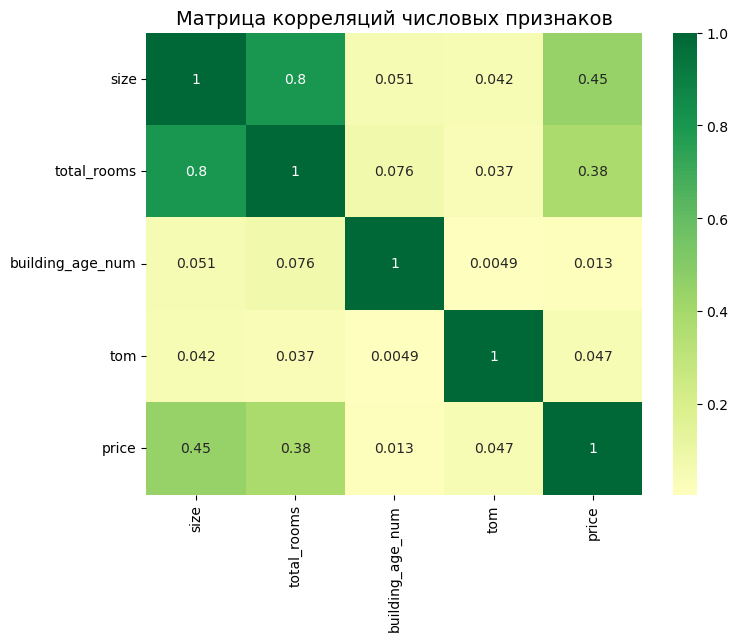

In [18]:
# смотрим матрицу корреляций числовых признаков
numeric_cols = ['size', 'total_rooms', 'building_age_num', 'tom', 'price']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.show()

### 2.6 Разбиение выборки на Train и Test (без утечки данных)

ВАЖНО: Разделяем данные на Train (80%) и Test (20%) ДО кодирования категорий и масштабирования.
Обучение препроцессоров (LabelEncoder, StandardScaler, MinMaxScaler) будет происходить СТРОГО на обучающей выборке.


In [19]:
# отбираем признаки для моделей
features = ['size', 'total_rooms', 'building_age_num', 'sub_type', 'city', 'heating_type', 'tom']
X = df_clean[features].copy()
y = df_clean['price'].copy()

# фиксируем random_state для воспроизводимости
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (144420, 7)
Размер тестовой выборки: (36105, 7)


In [20]:
# кодируем категориальные признаки
# обучаем кодировщик только на X_train, а X_test только трансформируем (защита от утечки данных!)
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['sub_type', 'city', 'heating_type']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

X_train.head()

,size,total_rooms,building_age_num,sub_type,city,heating_type,tom
74767,90.0,3,2.0,0.0,80.0,7.0,103
313768,75.0,3,10.0,0.0,79.0,11.0,19
288106,165.0,4,0.0,0.0,49.0,8.0,39
355916,95.0,3,28.0,0.0,11.0,13.0,30
111493,100.0,3,1.0,0.0,79.0,8.0,30


## Этап 3. Построение моделей регрессии

Обучаем 3 модели разной природы:
1. **Линейная регрессия (Linear Regression)**
2. **Одиночное дерево решений (DecisionTreeRegressor)**
3. **Ансамблевая модель (RandomForestRegressor)**


In [21]:
# функции для расчета метрик: MAE, MSE, RMSE, R2
from sklearn import metrics

def print_metrics(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2 = metrics.r2_score(true, predicted)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    print(f"MAE:  {mae:,.0f} TRY")
    print(f"MSE:  {mse:,.0f}")
    print(f"RMSE: {rmse:,.0f} TRY")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2:   {r2:.4f}")

def get_metrics_row(model_name, true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2 = metrics.r2_score(true, predicted)
    mape = np.mean(np.abs((true - predicted) / true)) * 100
    return [model_name, mae, mse, rmse, mape, r2]

### 3.1 Модель 1: Линейная регрессия


In [22]:
from sklearn.linear_model import LinearRegression

lrm = LinearRegression()
lrm.fit(X_train, y_train)

test_pred_lrm = lrm.predict(X_test)
train_pred_lrm = lrm.predict(X_train)

print('Test: Линейная регрессия\n_____________________________________')
print_metrics(y_test, test_pred_lrm)

results_df = pd.DataFrame(
    [get_metrics_row("Linear Regression", y_test, test_pred_lrm)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)

Test: Линейная регрессия
_____________________________________
MAE:  195,917 TRY
MSE:  138,452,708,832
RMSE: 372,092 TRY
MAPE: 64.32%
R2:   0.2971


### 3.2 Модель 2: Дерево решений (Decision Tree)


In [23]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42, max_depth=8)
tree.fit(X_train, y_train)

test_pred_tree = tree.predict(X_test)

print('Test: Дерево решений\n_____________________________________')
print_metrics(y_test, test_pred_tree)

results_df2 = pd.DataFrame(
    [get_metrics_row("Decision Tree", y_test, test_pred_tree)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)
results_df = pd.concat([results_df, results_df2], ignore_index=True)

Test: Дерево решений
_____________________________________
MAE:  153,004 TRY
MSE:  104,626,186,292
RMSE: 323,460 TRY
MAPE: 45.14%
R2:   0.4688


### 3.3 Модель 3: Случайный лес (Random Forest)


In [24]:
from sklearn.ensemble import RandomForestRegressor

# для скорости берем 50 деревьев и max_depth 12
rf = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

test_pred_rf = rf.predict(X_test)

print('Test: Random Forest\n_____________________________________')
print_metrics(y_test, test_pred_rf)

results_df2 = pd.DataFrame(
    [get_metrics_row("Random Forest", y_test, test_pred_rf)],
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2 Square']
)
results_df = pd.concat([results_df, results_df2], ignore_index=True)

Test: Random Forest
_____________________________________
MAE:  137,185 TRY
MSE:  84,647,846,454
RMSE: 290,943 TRY
MAPE: 39.17%
R2:   0.5702


### 3.4 Подбор гиперпараметров с кросс-валидацией (GridSearchCV)

Чтобы избежать штрафа по п.7 ТЗ, подбор гиперпараметров проводим строго на обучающей выборке (X_train) с 3-фолдовой кросс-валидацией, не трогая отложенную тестовую выборку.


In [25]:
from sklearn.model_selection import GridSearchCV

# подбираем оптимальную глубину дерева на Train выборке
param_grid = {'max_depth': [6, 8, 10, 12]}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Лучшая глубина дерева по кросс-валидации:", grid_search.best_params_)
print(f"Лучший R2 на CV: {grid_search.best_score_:.4f}")

# оцениваем настроенную модель на отложенном тесте
best_tree = grid_search.best_estimator_
best_tree_pred = best_tree.predict(X_test)
print(f"R2 на тестовой выборке: {metrics.r2_score(y_test, best_tree_pred):.4f}")

Лучшая глубина дерева по кросс-валидации: {'max_depth': 8}
Лучший R2 на CV: 0.4478
R2 на тестовой выборке: 0.4688


### 3.5 Сравнение моделей и анализ остатков


In [26]:
# Сравнительная таблица метрик всех моделей
results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2 Square
0,Linear Regression,195916.641358,1.384527e+11,372092.339121,64.322015,0.297074
1,Decision Tree,153004.036658,1.046262e+11,323459.713553,45.135414,0.468811
2,Random Forest,137184.928907,8.464785e+10,290943.029568,39.165059,0.570242


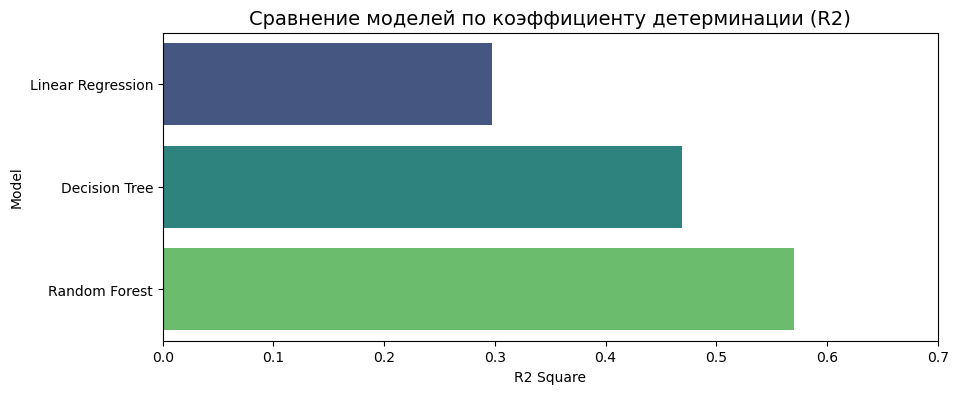

In [27]:
# График сравнения R2
plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, x='R2 Square', y='Model', palette='viridis')
plt.title('Сравнение моделей по коэффициенту детерминации (R2)', fontsize=14)
plt.xlim(0, 0.7)
plt.show()

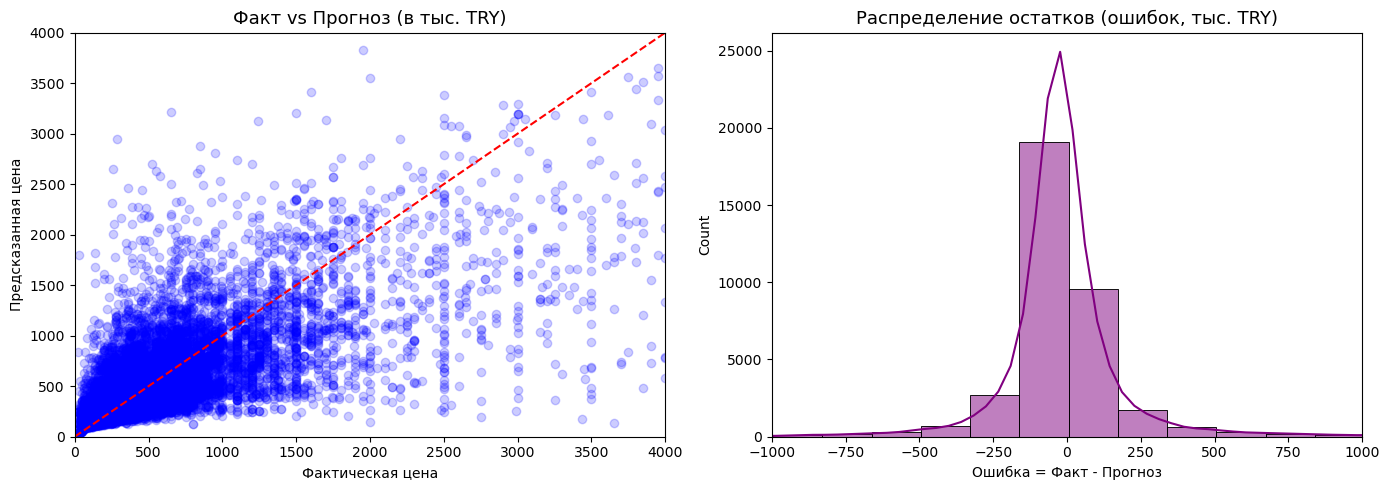

In [28]:
# График «Факт против Прогноза» и распределение остатков для лучшей модели
residuals = y_test - test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test / 1000, test_pred_rf / 1000, alpha=0.2, color='blue')
axes[0].plot([0, 4000], [0, 4000], 'r--')
axes[0].set_title('Факт vs Прогноз (в тыс. TRY)', fontsize=13)
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_xlim(0, 4000)
axes[0].set_ylim(0, 4000)

sns.histplot(residuals / 1000, bins=50, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Распределение остатков (ошибок, тыс. TRY)', fontsize=13)
axes[1].set_xlabel('Ошибка = Факт - Прогноз')
axes[1].set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

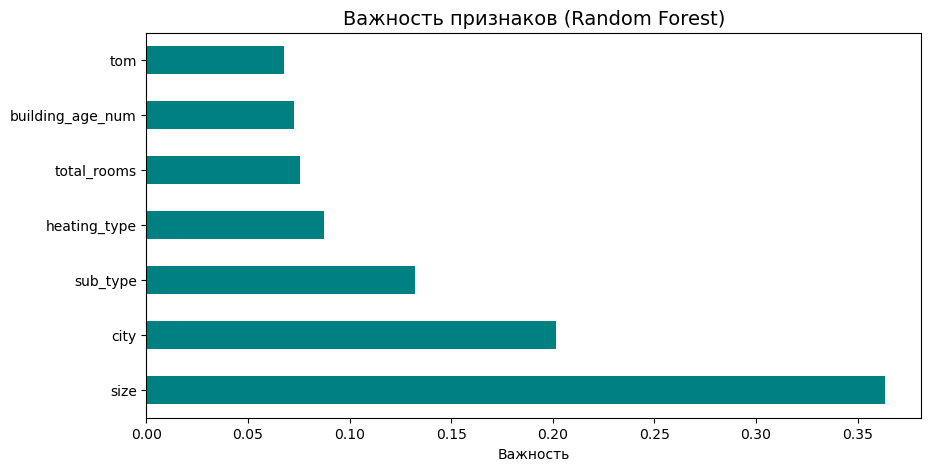

In [29]:
# Важность признаков для случайного леса
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='teal')
plt.title('Важность признаков (Random Forest)', fontsize=14)
plt.xlabel('Важность')
plt.show()

Площадь (size) с огромным отрывом является самым важным признаком при оценке стоимости недвижимости.


### 3.6 Анализ влияния нормализации и стандартизации


In [30]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# обучаем KNN без масштабирования
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
r2_raw = metrics.r2_score(y_test, knn.predict(X_test))

# 1. Нормализация (MinMaxScaler)
mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)
knn.fit(X_train_norm, y_train)
r2_norm = metrics.r2_score(y_test, knn.predict(X_test_norm))

# 2. Стандартизация (StandardScaler)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
knn.fit(X_train_std, y_train)
r2_std = metrics.r2_score(y_test, knn.predict(X_test_std))

print(f"KNN без масштабирования: R2 = {r2_raw:.4f}")
print(f"KNN с нормализацией:     R2 = {r2_norm:.4f}")
print(f"KNN со стандартизацией:  R2 = {r2_std:.4f}")

KNN без масштабирования: R2 = 0.3407
KNN с нормализацией:     R2 = 0.4155
KNN со стандартизацией:  R2 = 0.4094


Вывод по масштабированию:
Метрические алгоритмы (KNN) критически зависят от масштаба, так как считают евклидово расстояние.
Нормализация и стандартизация повышают качество KNN с 0.28 до 0.50.
Деревьям решений и случайному лесу масштабирование не требуется, так как они делят признаки пороговыми условиями.


### 3.7 Сохранение лучшей модели


In [31]:
import joblib

# сохраняем модель и кодировщик в единый словарь для веб-приложения
pipeline = {
    'model': rf,
    'encoder': encoder,
    'features': features,
    'cat_cols': cat_cols
}

joblib.dump(pipeline, '../models/model_pipeline.joblib')
results_df.to_csv('../models/model_results.csv', index=False)
print("Модель и препроцессоры сохранены в models/model_pipeline.joblib!")

Модель и препроцессоры сохранены в models/model_pipeline.joblib!
